# 5. Caracterización de perfiles de resistencia fiscal

Este notebook caracteriza los tres clusters identificados por K-means 
sobre el universo de 797.161 contribuyentes con obligación activa de 
declarar IVA en Ecuador (período 2020–2025).

Los tres perfiles identificados son:

| Cluster | N | % | Denominación provisional |
|---|---|---|---|
| 1 | 60.980 | 7,6% | Grandes contribuyentes — cumplimiento alto |
| 0 | 499.822 | 62,7% | Contribuyentes medianos — pago parcial |
| 2 | 236.359 | 29,6% | Declarantes sin pago efectivo |

In [1]:
import sys, os
ROOT = r"D:\inf_sri_hist3\z_CLUSTER"
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

import config
import importlib
importlib.reload(config)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 150, "figure.figsize": (10, 5),
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11,
})

# Paleta por cluster — orden interpretativo: C1, C0, C2
COLORES = {0: "#2171b5", 1: "#238b45", 2: "#d94801"}
NOMBRES = {
    0: "Cluster 0 — Medianos/pago parcial",
    1: "Cluster 1 — Grandes/cumplimiento alto",
    2: "Cluster 2 — Declarantes sin pago",
}

# Cargar dataset original con etiquetas
df = pd.read_parquet(config.PARQUET_FILE)
labels = pd.read_parquet(config.DATA_DIR / "B02_LABELS_CLUSTERING.parquet")
df = df.merge(labels, on="ID", how="left")

print(f"Dataset cargado: {df.shape[0]:,} filas")
print(f"Distribución de clusters:")
for k in [1, 0, 2]:
    n = (df["cluster_km3"] == k).sum()
    print(f"  {NOMBRES[k]}: {n:,} ({n/len(df)*100:.2f}%)")

Dataset cargado: 797,161 filas
Distribución de clusters:
  Cluster 1 — Grandes/cumplimiento alto: 60,980 (7.65%)
  Cluster 0 — Medianos/pago parcial: 499,822 (62.70%)
  Cluster 2 — Declarantes sin pago: 236,359 (29.65%)


## 5.1 Perfil cuantitativo por cluster

Estadísticos clave sobre variables de comportamiento fiscal, 
tamaño económico y cumplimiento formal.

In [2]:
# Tabla de caracterización cuantitativa
vars_carac = {
    "Tamaño económico": [
        "tot_v_grav_nta", "I_ingresos_avg", "tot_iva_causado",
    ],
    "Comportamiento de pago": [
        "reca_total_f05", "tot_iva_pagado", "tasa_tardio",
        "promedio_dias_demora",
    ],
    "Cumplimiento formal": [
        "tasa_omision", "n_meses_cubiertos", "pct_decl_con_mora",
        "pct_decl_cero",
    ],
    "Red económica": [
        "tot_ret_recibidas", "n_establ_total",
    ],
}

print("CARACTERIZACIÓN CUANTITATIVA — MEDIANA POR CLUSTER")
print("=" * 70)
for grupo, variables in vars_carac.items():
    print(f"\n{grupo}:")
    tbl = df.groupby("cluster_km3")[variables].median()
    display(tbl.T.style.format("{:,.2f}"))

CARACTERIZACIÓN CUANTITATIVA — MEDIANA POR CLUSTER

Tamaño económico:


cluster_km3,0,1,2
tot_v_grav_nta,"42,640.94","1,009,472.49",0.04
I_ingresos_avg,"16,041.99","437,264.35","12,092.03"
tot_iva_causado,"2,717.78","53,403.98",0.00



Comportamiento de pago:


cluster_km3,0,1,2
reca_total_f05,19.78,"27,285.99",0.00
tot_iva_pagado,75.43,"24,874.87",7.27
tasa_tardio,0.50,0.57,0.46
promedio_dias_demora,14.14,0.97,14.76



Cumplimiento formal:


cluster_km3,0,1,2
tasa_omision,0.00,0.00,0.00
n_meses_cubiertos,63.00,72.00,68.00
pct_decl_con_mora,0.13,0.04,0.09
pct_decl_cero,0.00,0.00,0.00



Red económica:


cluster_km3,0,1,2
tot_ret_recibidas,"1,377.78","22,063.28",0.00
n_establ_total,1.00,2.00,1.00


In [3]:
# Tabla de flags — proporciones
flags_carac = [
    "flag_sin_recaudacion_f05",
    "flg_sin_perfil_f02",
    "flg_es_retenido",
    "flg_es_retenedor",
    "flag_persona_natural",
    "flag_rimpe",
    "flag_gran_contrib",
    "flag_obligado_contab",
]

# Filtrar solo las que existen en el dataset
flags_presentes = [f for f in flags_carac if f in df.columns]

print("PROPORCIÓN DE FLAGS POR CLUSTER")
print("=" * 55)
tbl_flags = (df.groupby("cluster_km3")[flags_presentes]
             .mean()
             .mul(100)
             .round(2))
display(tbl_flags.T.style.format("{:.2f}%"))

PROPORCIÓN DE FLAGS POR CLUSTER


cluster_km3,0,1,2
flag_sin_recaudacion_f05,27.38%,0.06%,65.61%
flg_sin_perfil_f02,3.77%,0.03%,7.03%
flg_es_retenido,78.33%,93.61%,59.49%
flg_es_retenedor,0.84%,91.71%,1.69%
flag_persona_natural,90.50%,36.01%,92.37%
flag_rimpe,4.47%,0.31%,5.21%
flag_gran_contrib,0.01%,0.87%,0.00%
flag_obligado_contab,11.01%,95.92%,9.44%


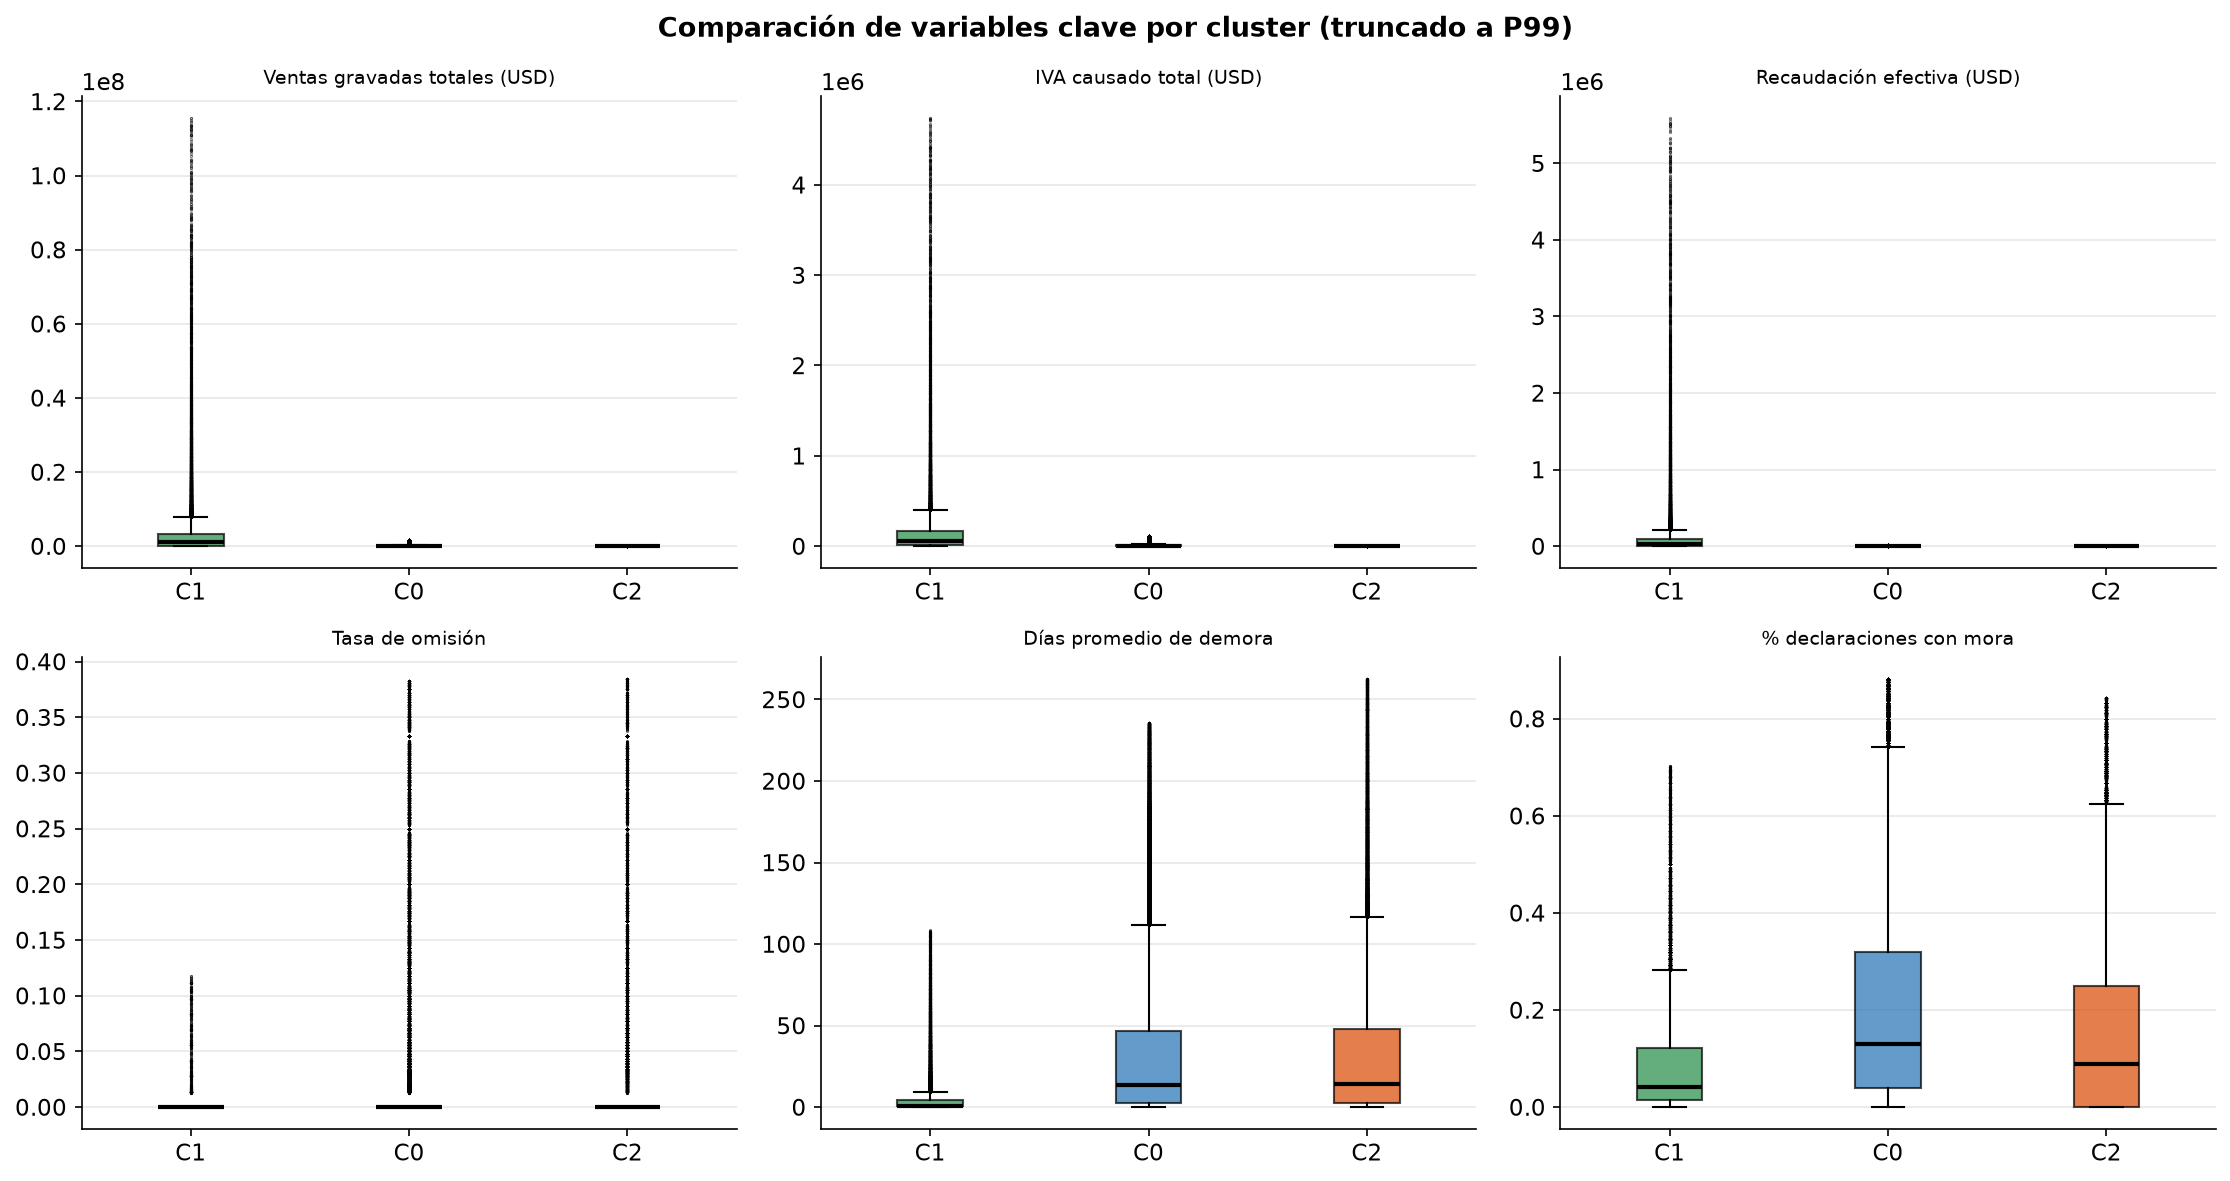

In [4]:
# Figura — comparación de variables clave por cluster
vars_fig = [
    ("tot_v_grav_nta",       "Ventas gravadas totales (USD)"),
    ("tot_iva_causado",      "IVA causado total (USD)"),
    ("reca_total_f05",       "Recaudación efectiva (USD)"),
    ("tasa_omision",         "Tasa de omisión"),
    ("promedio_dias_demora", "Días promedio de demora"),
    ("pct_decl_con_mora",    "% declaraciones con mora"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (v, lbl) in enumerate(vars_fig):
    data_plot = []
    etiquetas = []
    colores_box = []
    for k in [1, 0, 2]:
        data_k = df.loc[df["cluster_km3"] == k, v].dropna()
        p99 = data_k.quantile(0.99)
        data_plot.append(data_k[data_k <= p99].values)
        etiquetas.append(f"C{k}")
        colores_box.append(COLORES[k])

    bp = axes[i].boxplot(data_plot, patch_artist=True,
                          medianprops={"color": "black", "linewidth": 2},
                          flierprops={"marker": ".", "markersize": 1,
                                      "alpha": 0.3})
    for patch, color in zip(bp["boxes"], colores_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    axes[i].set_xticklabels(etiquetas)
    axes[i].set_title(lbl, fontsize=9)
    axes[i].grid(axis="y", alpha=0.3)

fig.suptitle("Comparación de variables clave por cluster (truncado a P99)",
             fontweight="bold")
plt.tight_layout()
plt.savefig(config.OUT_DIR / "fig12_caracterizacion_boxplots.png",
            bbox_inches="tight")
plt.show()

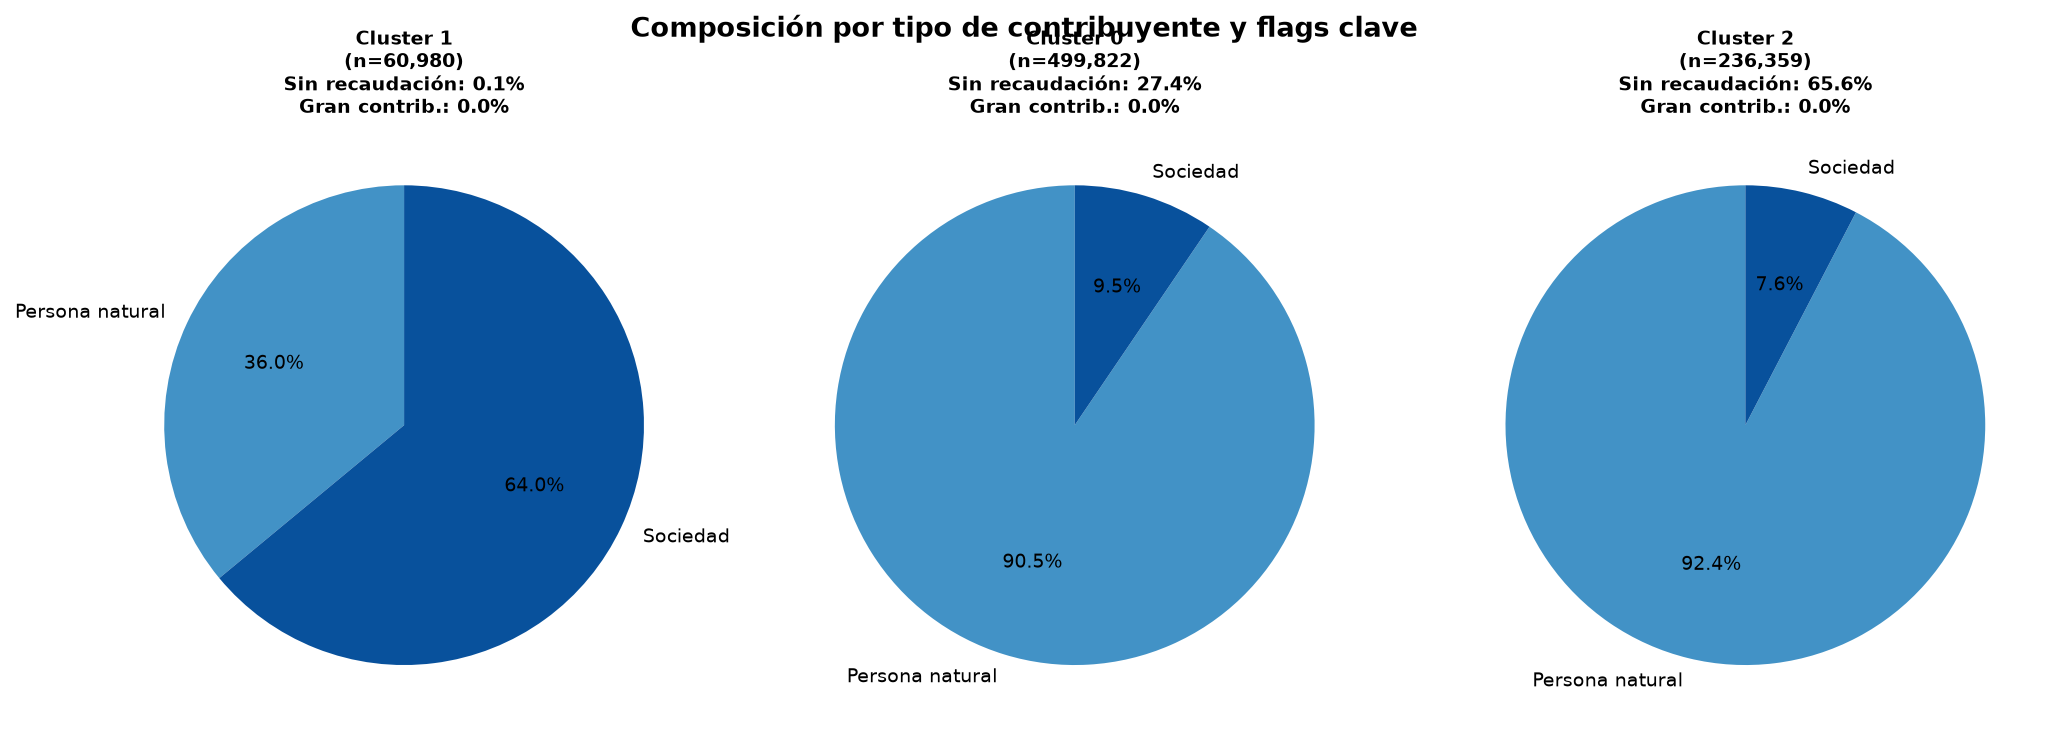

In [5]:
# Figura — composición por tipo de contribuyente
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, k in enumerate([1, 0, 2]):
    df_k = df[df["cluster_km3"] == k]
    n_pn = df_k["flag_persona_natural"].sum() if "flag_persona_natural" in df_k else 0
    n_soc = len(df_k) - n_pn
    pct_rimpe = df_k["flag_rimpe"].mean() * 100 if "flag_rimpe" in df_k else 0
    pct_gc    = df_k["flag_gran_contribuyente"].mean() * 100 \
                if "flag_gran_contribuyente" in df_k else 0
    pct_sr = df_k["flag_sin_recaudacion_f05"].mean() * 100

    valores = [n_pn/len(df_k)*100, n_soc/len(df_k)*100]
    etiq    = ["Persona natural", "Sociedad"]
    colores_pie = ["#4292c6", "#08519c"]

    axes[i].pie(valores, labels=etiq, colors=colores_pie,
                autopct="%1.1f%%", startangle=90,
                textprops={"fontsize": 9})
    axes[i].set_title(f"Cluster {k}\n(n={len(df_k):,})\n"
                      f"Sin recaudación: {pct_sr:.1f}%\n"
                      f"Gran contrib.: {pct_gc:.1f}%",
                      fontsize=9, fontweight="bold")

fig.suptitle("Composición por tipo de contribuyente y flags clave",
             fontweight="bold")
plt.tight_layout()
plt.savefig(config.OUT_DIR / "fig13_composicion_clusters.png",
            bbox_inches="tight")
plt.show()

## 5.2 Interpretación de perfiles de resistencia fiscal

Los tres clusters revelan patrones diferenciados de comportamiento 
fiscal que permiten operacionalizar el concepto de resistencia fiscal 
en sus distintas manifestaciones (Tanzi y Shome, 1993).

In [6]:
# Tabla resumen de perfiles — para exportar a la tesis
perfiles = pd.DataFrame({
    "Dimensión": [
        "N contribuyentes", "% universo",
        "Ventas gravadas medianas (USD)", "IVA causado mediano (USD)",
        "Recaudación efectiva mediana (USD)", "Ingresos promedio medianos (USD)",
        "% sin recaudación efectiva", "Tasa tardío mediana",
        "Días demora promedio (mediana)", "Tasa omisión mediana",
        "Meses cubiertos (mediana)", "% personas naturales",
        "% agente de retención", "% obligado contabilidad",
        "% RIMPE",
    ],
    "Cluster 1\nAlto valor": [
        "60.980", "7,65%",
        "1.009.472", "53.404", "27.286", "437.264",
        "0,06%", "0,57", "0,97", "0,00",
        "72", "36,0%", "91,7%", "95,9%", "0,3%",
    ],
    "Cluster 0\nMediano/brecha": [
        "499.822", "62,70%",
        "42.641", "2.718", "20", "16.042",
        "27,4%", "0,50", "14,14", "0,00",
        "63", "90,5%", "0,8%", "11,0%", "4,5%",
    ],
    "Cluster 2\nDeclarante formal": [
        "236.359", "29,65%",
        "0", "0", "0", "12.092",
        "65,6%", "0,46", "14,76", "0,00",
        "68", "92,4%", "1,7%", "9,4%", "5,2%",
    ],
})

display(perfiles.set_index("Dimensión").style
        .set_properties(**{"text-align": "right"})
        .set_table_styles([{
            "selector": "th",
            "props": [("text-align", "center"), ("font-weight", "bold")]
        }]))

,Cluster 1 Alto valor,Cluster 0 Mediano/brecha,Cluster 2 Declarante formal
Dimensión,,,
N contribuyentes,60.980,499.822,236.359
% universo,"7,65%","62,70%","29,65%"
Ventas gravadas medianas (USD),1.009.472,42.641,0
IVA causado mediano (USD),53.404,2.718,0
Recaudación efectiva mediana (USD),27.286,20,0
Ingresos promedio medianos (USD),437.264,16.042,12.092
% sin recaudación efectiva,"0,06%","27,4%","65,6%"
Tasa tardío mediana,"0,57","0,50","0,46"
Días demora promedio (mediana),"0,97","14,14","14,76"


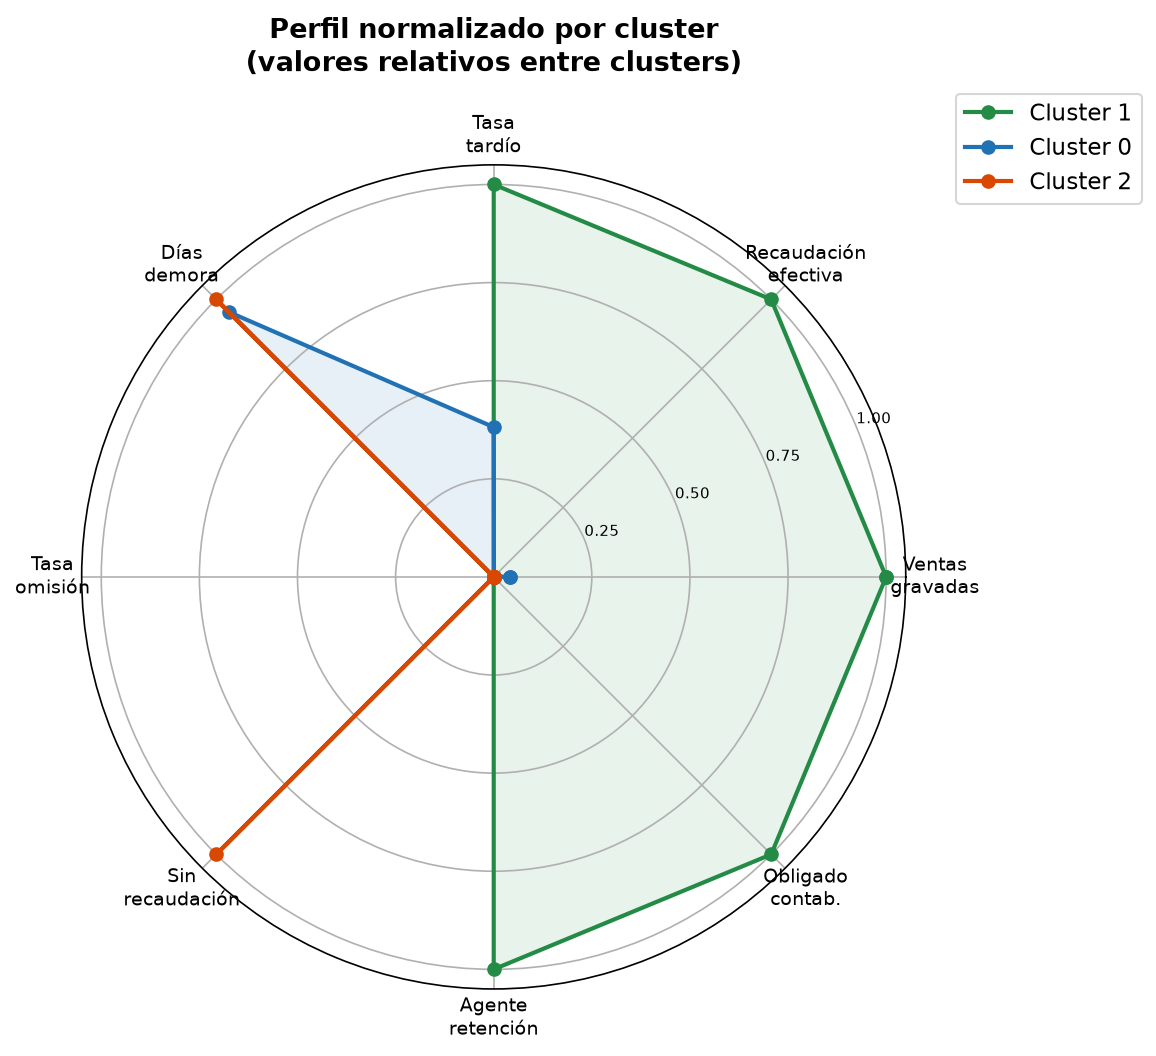

In [7]:
# Figura — radar chart de perfiles
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Variables normalizadas para radar (0-1 por variable)
vars_radar = [
    "tot_v_grav_nta", "reca_total_f05", "tasa_tardio",
    "promedio_dias_demora", "tasa_omision", "flag_sin_recaudacion_f05",
    "flg_es_retenedor", "flag_obligado_contab",
]
etiq_radar = [
    "Ventas\ngravadas", "Recaudación\nefectiva", "Tasa\ntardío",
    "Días\ndemora", "Tasa\nomisión", "Sin\nrecaudación",
    "Agente\nretención", "Obligado\ncontab.",
]

# Medianas por cluster
med_radar = df.groupby("cluster_km3")[vars_radar].median()

# Normalizar 0-1
med_norm = (med_radar - med_radar.min()) / (med_radar.max() - med_radar.min() + 1e-9)

N = len(vars_radar)
angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})

for k in [1, 0, 2]:
    valores = med_norm.loc[k].values.tolist()
    valores += valores[:1]
    ax.plot(angulos, valores, "o-", linewidth=2,
            color=COLORES[k], label=f"Cluster {k}")
    ax.fill(angulos, valores, alpha=0.1, color=COLORES[k])

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(etiq_radar, size=9)
ax.set_yticks([0.25, 0.50, 0.75, 1.00])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], size=7)
ax.set_title("Perfil normalizado por cluster\n(valores relativos entre clusters)",
             fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig(config.OUT_DIR / "fig14_radar_perfiles.png", bbox_inches="tight")
plt.show()

## 5.3 Recomendaciones operativas para el SRI

Con base en los perfiles identificados, se proponen las siguientes 
líneas de acción diferenciadas por cluster.

In [8]:
# Tabla de recomendaciones operativas
recomendaciones = pd.DataFrame({
    "Cluster": [
        "Cluster 1\n(60.980 contrib.)",
        "Cluster 0\n(499.822 contrib.)",
        "Cluster 2\n(236.359 contrib.)",
    ],
    "Perfil de riesgo": [
        "Bajo — incumplimiento formal mínimo",
        "Medio-alto — brecha sistemática declaración/pago",
        "Medio — cumplimiento formal sin pago efectivo",
    ],
    "Mecanismo de resistencia": [
        "Posible elusión sofisticada\n(no capturable con estas variables)",
        "Subdeclaración o aplazamiento\ndel pago efectivo",
        "Actividad en tarifa 0% o crédito\ntributario permanente — requiere verificación",
    ],
    "Acción prioritaria SRI": [
        "Auditoría de precios de transferencia\ny estructuras de planificación fiscal",
        "Campaña de regularización de deuda;\nfacilidades de pago; control de morosidad",
        "Verificación de aplicación correcta\nde tarifa 0%; cruce con F04 para detectar\nactividad gravada no declarada",
    ],
    "Instrumento": [
        "Determinación tributaria\nfocalizada",
        "Gestión de cartera vencida;\naviso automático de vencimiento",
        "Control de consistencia\nF01 vs F04 (facturación electrónica)",
    ],
})

display(recomendaciones.set_index("Cluster").style
        .set_properties(**{"white-space": "pre-wrap", "text-align": "left"})
        .set_table_styles([{
            "selector": "th",
            "props": [("font-weight", "bold"), ("text-align", "center")]
        }]))

,Perfil de riesgo,Mecanismo de resistencia,Acción prioritaria SRI,Instrumento
Cluster,,,,
Cluster 1 (60.980 contrib.),Bajo — incumplimiento formal mínimo,Posible elusión sofisticada (no capturable con estas variables),Auditoría de precios de transferencia y estructuras de planificación fiscal,Determinación tributaria focalizada
Cluster 0 (499.822 contrib.),Medio-alto — brecha sistemática declaración/pago,Subdeclaración o aplazamiento del pago efectivo,Campaña de regularización de deuda; facilidades de pago; control de morosidad,Gestión de cartera vencida; aviso automático de vencimiento
Cluster 2 (236.359 contrib.),Medio — cumplimiento formal sin pago efectivo,Actividad en tarifa 0% o crédito tributario permanente — requiere verificación,Verificación de aplicación correcta de tarifa 0%; cruce con F04 para detectar actividad gravada no declarada,Control de consistencia F01 vs F04 (facturación electrónica)


In [9]:
# Guardar tabla de perfiles para referencia en tesis
perfiles.to_csv(config.OUT_DIR / "tabla_perfiles_clusters.csv",
                index=False, encoding="utf-8-sig")

print("PIPELINE PYTHON COMPLETADO")
print("=" * 55)
print(f"\nArchivos generados en {config.DATA_DIR}:")
for f in sorted(config.DATA_DIR.glob("B0*")):
    print(f"  {f.name:<45s} {f.stat().st_size/1e6:.1f} MB")

print(f"\nFiguras generadas en {config.OUT_DIR}:")
for f in sorted(config.OUT_DIR.glob("fig*.png")):
    print(f"  {f.name}")

print(f"\nResumen final:")
print(f"  Universo analizado        : 797.161 contribuyentes")
print(f"  Variables de clustering   : 68")
print(f"  Algoritmo seleccionado    : K-means K=3")
print(f"  Cluster 1 (alto valor)    : 60.980 (7,65%)")
print(f"  Cluster 0 (mediano/brecha): 499.822 (62,70%)")
print(f"  Cluster 2 (declarante)    : 236.359 (29,65%)")

PIPELINE PYTHON COMPLETADO

Archivos generados en D:\inf_sri_hist3\z_CLUSTER\data:
  B00_DATASET_ANALITICO_INTEGRADO.dta           1007.8 MB
  B00_DATASET_ANALITICO_INTEGRADO.parquet       404.2 MB
  B01_MATRIZ_CLUSTERING.parquet                 196.8 MB
  B02_LABELS_CLUSTERING.parquet                 3.7 MB
  B03_SCORES_ATIPICIDAD.parquet                 32.6 MB

Figuras generadas en D:\inf_sri_hist3\z_CLUSTER\outputs:
  fig01_cobertura_por_fuente.png
  fig02_missings_clustering.png
  fig03_f01_monetarias_dist.png
  fig04_f01_proporcionales_dist.png
  fig05_f02f06_dist.png
  fig06_efecto_log_transform.png
  fig07_corr_f01_heatmap.png
  fig08_corr_f02f07_heatmap.png
  fig09_kmeans_metricas.png
  fig10_kmeans_pca.png
  fig11_dbscan_eps_calibracion.png
  fig12_caracterizacion_boxplots.png
  fig13_composicion_clusters.png
  fig14_radar_perfiles.png
  fig15_score_distribucion_violin.png
  fig16_score_pca_gradiente.png
  fig17_top_vars_atipicos_c0.png
  fig18_pca_scree_varianza.png

Resumen

In [10]:
from sklearn.decomposition import PCA
import numpy as np

X = pd.read_parquet(config.DATA_DIR / "B01_MATRIZ_CLUSTERING.parquet")
X = X[config.CLUSTER_VARS_FINAL].values

pca = PCA(n_components=2, random_state=42)
pca.fit(X)
print(f"Varianza explicada PC1 : {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Varianza explicada PC2 : {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total PC1+PC2          : {sum(pca.explained_variance_ratio_)*100:.2f}%")

Varianza explicada PC1 : 17.19%
Varianza explicada PC2 : 8.19%
Total PC1+PC2          : 25.39%


## 5.4 Score de atipicidad y priorización de riesgo

Se construye un score de atipicidad para cada contribuyente que permite 
ordenar, dentro de cada cluster, los casos de mayor a menor distancia 
respecto al comportamiento típico del grupo. El score combina dos métricas 
complementarias: la distancia euclidiana al centroide del cluster asignado 
(medida de alejamiento del patrón central) y el coeficiente de silueta 
individual (medida de pertenencia al cluster propio frente al vecino más 
cercano). Ambas se normalizan a [0,1] y se combinan en un score único 
que sirve como criterio de priorización operativa.

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
import json

# Recargar matriz y etiquetas
X_mat = pd.read_parquet(config.DATA_DIR / "B01_MATRIZ_CLUSTERING.parquet")
IDs_score = X_mat["ID"].values
X_arr = X_mat[config.CLUSTER_VARS_FINAL].values

# Re-entrenar K-means con mismos parámetros para obtener centroides
print("Re-entrenando K-means para extraer centroides...")
km_score = KMeans(n_clusters=3, random_state=42, n_init=20, max_iter=500)
labels_score = km_score.fit_predict(X_arr)
centroides = km_score.cluster_centers_

print(f"Clusters: {dict(zip(*np.unique(labels_score, return_counts=True)))}")

Re-entrenando K-means para extraer centroides...
Clusters: {np.int32(0): np.int64(499822), np.int32(1): np.int64(60980), np.int32(2): np.int64(236359)}


In [12]:
# Score 1 — Distancia euclidiana al centroide del cluster asignado
print("Calculando distancias al centroide...")
distancias = np.array([
    np.linalg.norm(X_arr[i] - centroides[labels_score[i]])
    for i in range(len(X_arr))
])
print(f"Distancia media global: {distancias.mean():.4f}")
print(f"Distancia máxima      : {distancias.max():.4f}")

Calculando distancias al centroide...
Distancia media global: 7.2300
Distancia máxima      : 42.3712


In [13]:
# Score 2 — Silueta individual (muestra estratificada por costo)
print("Calculando silueta individual (muestra 50k)...")
np.random.seed(42)
idx_sil = np.random.choice(len(X_arr), size=50_000, replace=False)
sil_muestra = silhouette_samples(X_arr[idx_sil], labels_score[idx_sil])

# Extender al universo completo mediante interpolación por cluster
# Para puntos no muestreados se usa la mediana de silueta de su cluster
sil_full = np.zeros(len(X_arr))
sil_full[idx_sil] = sil_muestra

medianas_sil = {}
for k in range(3):
    mask_k_sil = idx_sil[labels_score[idx_sil] == k]
    medianas_sil[k] = sil_muestra[labels_score[idx_sil] == k].median() \
                      if hasattr(sil_muestra[labels_score[idx_sil] == k], 'median') \
                      else np.median(sil_muestra[labels_score[idx_sil] == k])

# Para los no muestreados, imputar mediana del cluster
idx_no_sil = np.setdiff1d(np.arange(len(X_arr)), idx_sil)
for i in idx_no_sil:
    sil_full[i] = medianas_sil[labels_score[i]]

print("Medianas de silueta por cluster:")
for k in range(3):
    mask_k = labels_score == k
    print(f"  Cluster {k}: {np.median(sil_full[mask_k]):.4f}")

Calculando silueta individual (muestra 50k)...
Medianas de silueta por cluster:
  Cluster 0: 0.1512
  Cluster 1: 0.1246
  Cluster 2: 0.1311


In [14]:
# Normalización y score combinado
def normalizar_01(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-9)

# Distancia normalizada: mayor distancia = mayor atipicidad
dist_norm = normalizar_01(distancias)

# Silueta normalizada e invertida: silueta baja (o negativa) = mayor atipicidad
sil_norm_inv = 1 - normalizar_01(sil_full)

# Score combinado (pesos iguales — ajustable)
PESO_DIST = 0.6
PESO_SIL  = 0.4
score_combinado = PESO_DIST * dist_norm + PESO_SIL * sil_norm_inv

# Percentil dentro del cluster (100 = más atípico)
percentil_intracluster = np.zeros(len(X_arr))
for k in range(3):
    mask_k = labels_score == k
    scores_k = score_combinado[mask_k]
    from scipy.stats import rankdata
    percentil_intracluster[mask_k] = rankdata(scores_k) / mask_k.sum() * 100

print("Score combinado — estadísticos globales:")
print(f"  Media  : {score_combinado.mean():.4f}")
print(f"  Mediana: {np.median(score_combinado):.4f}")
print(f"  P95    : {np.percentile(score_combinado, 95):.4f}")
print(f"  P99    : {np.percentile(score_combinado, 99):.4f}")

Score combinado — estadísticos globales:
  Media  : 0.2187
  Mediana: 0.2127
  P95    : 0.2854
  P99    : 0.3491


In [15]:
# Construir DataFrame de scores
df_scores = pd.DataFrame({
    "ID"                    : IDs_score,
    "cluster_km3"           : labels_score,
    "dist_centroide"        : distancias,
    "dist_centroide_norm"   : dist_norm,
    "silueta_individual"    : sil_full,
    "silueta_norm_inv"      : sil_norm_inv,
    "score_atipicidad"      : score_combinado,
    "percentil_intracluster": percentil_intracluster,
})

# Nivel de prioridad operativa (quintiles del score por cluster)
df_scores["nivel_prioridad"] = 0
for k in range(3):
    mask_k = df_scores["cluster_km3"] == k
    q = df_scores.loc[mask_k, "score_atipicidad"].quantile([.80, .90, .95, .99])
    condiciones = [
        df_scores.loc[mask_k, "score_atipicidad"] >= q[0.99],
        df_scores.loc[mask_k, "score_atipicidad"] >= q[0.95],
        df_scores.loc[mask_k, "score_atipicidad"] >= q[0.90],
        df_scores.loc[mask_k, "score_atipicidad"] >= q[0.80],
    ]
    niveles = [5, 4, 3, 2]
    df_scores.loc[mask_k, "nivel_prioridad"] = np.select(condiciones, niveles, default=1)

print("Distribución de niveles de prioridad por cluster:")
print(df_scores.groupby(["cluster_km3", "nivel_prioridad"]).size()
      .unstack(fill_value=0).to_string())

Distribución de niveles de prioridad por cluster:
nivel_prioridad       1      2      3      4     5
cluster_km3                                       
0                399857  49982  24991  19993  4999
1                 48784   6098   3049   2439   610
2                189087  23636  11818   9454  2364


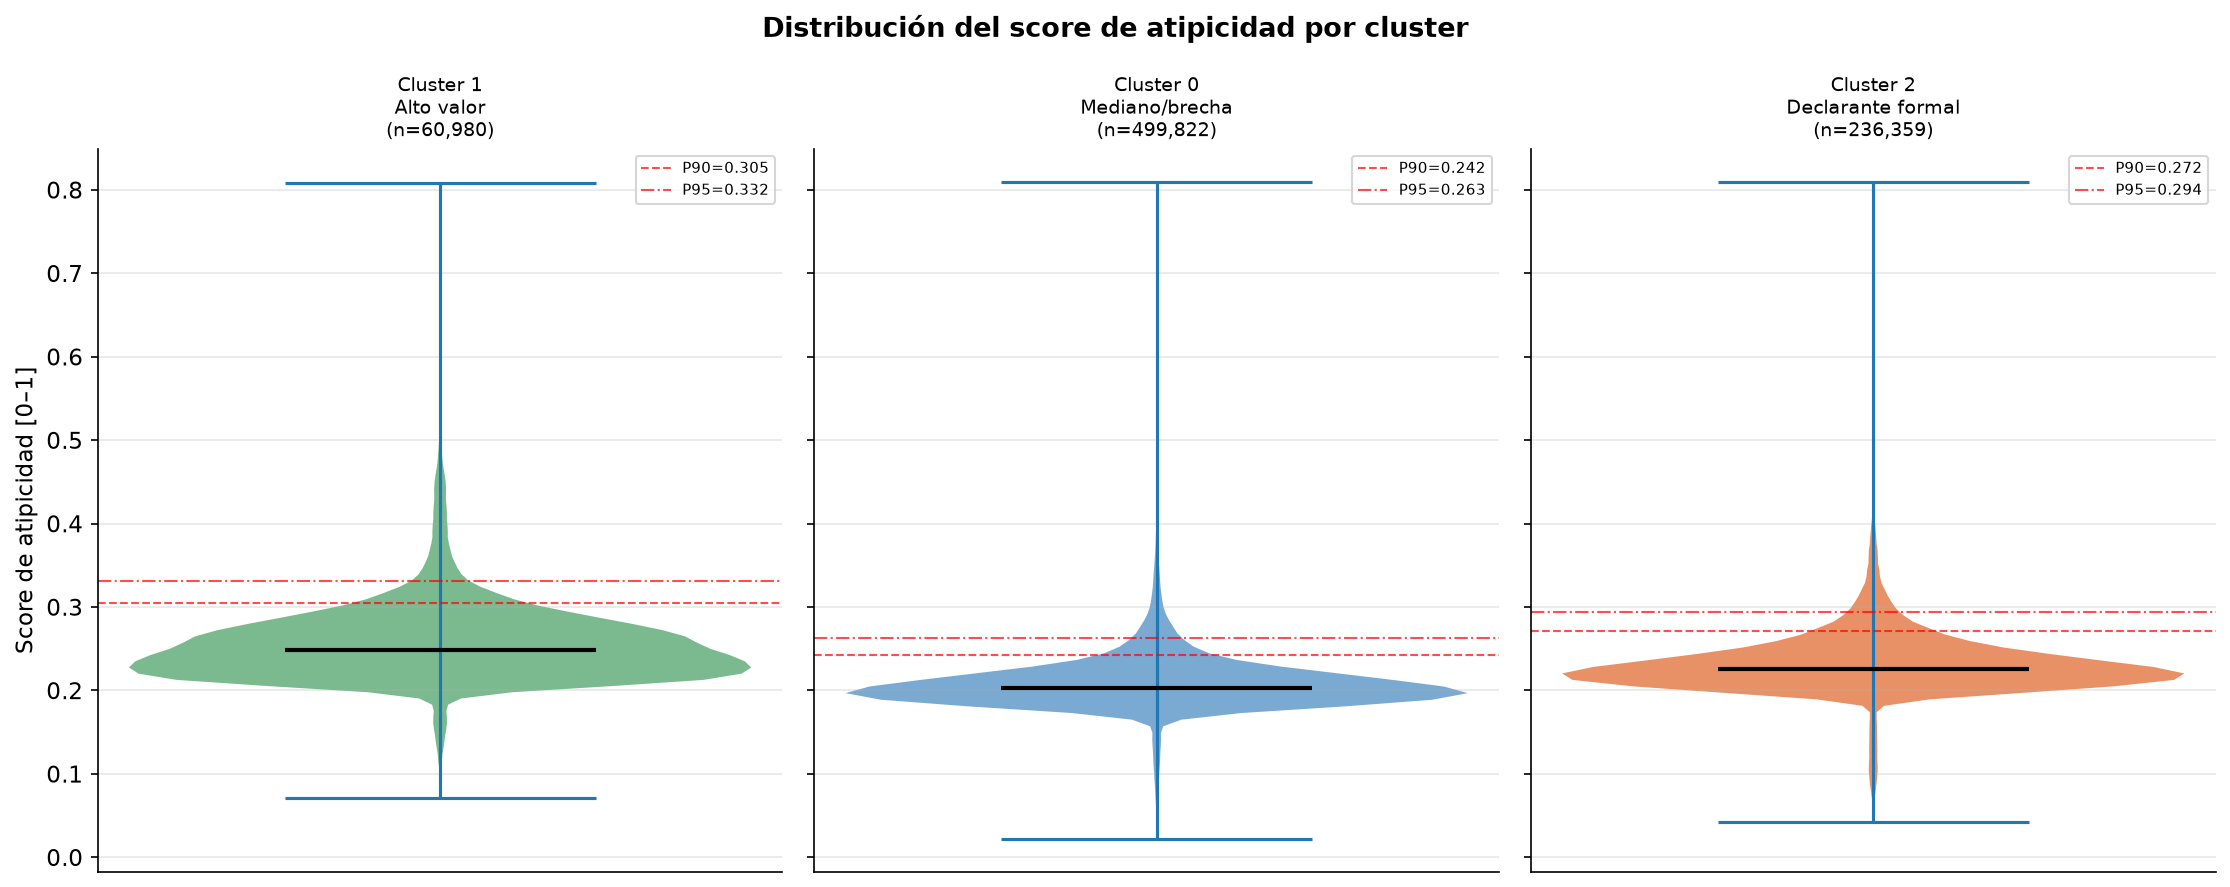

In [16]:
# FIGURA A — Distribución del score por cluster (violin + boxplot)
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

nombres_c = {0: "Cluster 0\nMediano/brecha", 
             1: "Cluster 1\nAlto valor",
             2: "Cluster 2\nDeclarante formal"}

for i, k in enumerate([1, 0, 2]):
    datos_k = df_scores.loc[df_scores["cluster_km3"] == k, "score_atipicidad"]
    
    vp = axes[i].violinplot(datos_k, positions=[0], 
                             showmedians=True, showextrema=True)
    for body in vp["bodies"]:
        body.set_facecolor(COLORES[k])
        body.set_alpha(0.6)
    vp["cmedians"].set_color("black")
    vp["cmedians"].set_linewidth(2)
    
    # Percentiles clave
    for p, ls in [(90, "--"), (95, "-.")]:
        val = np.percentile(datos_k, p)
        axes[i].axhline(val, color="red", linestyle=ls, 
                        linewidth=1, alpha=0.7,
                        label=f"P{p}={val:.3f}")
    
    axes[i].set_title(f"{nombres_c[k]}\n(n={len(datos_k):,})", fontsize=9)
    axes[i].set_xticks([])
    axes[i].legend(fontsize=7)
    axes[i].grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Score de atipicidad [0–1]")
fig.suptitle("Distribución del score de atipicidad por cluster",
             fontweight="bold")
plt.tight_layout()
plt.savefig(config.OUT_DIR / "fig15_score_distribucion_violin.png",
            bbox_inches="tight")
plt.show()

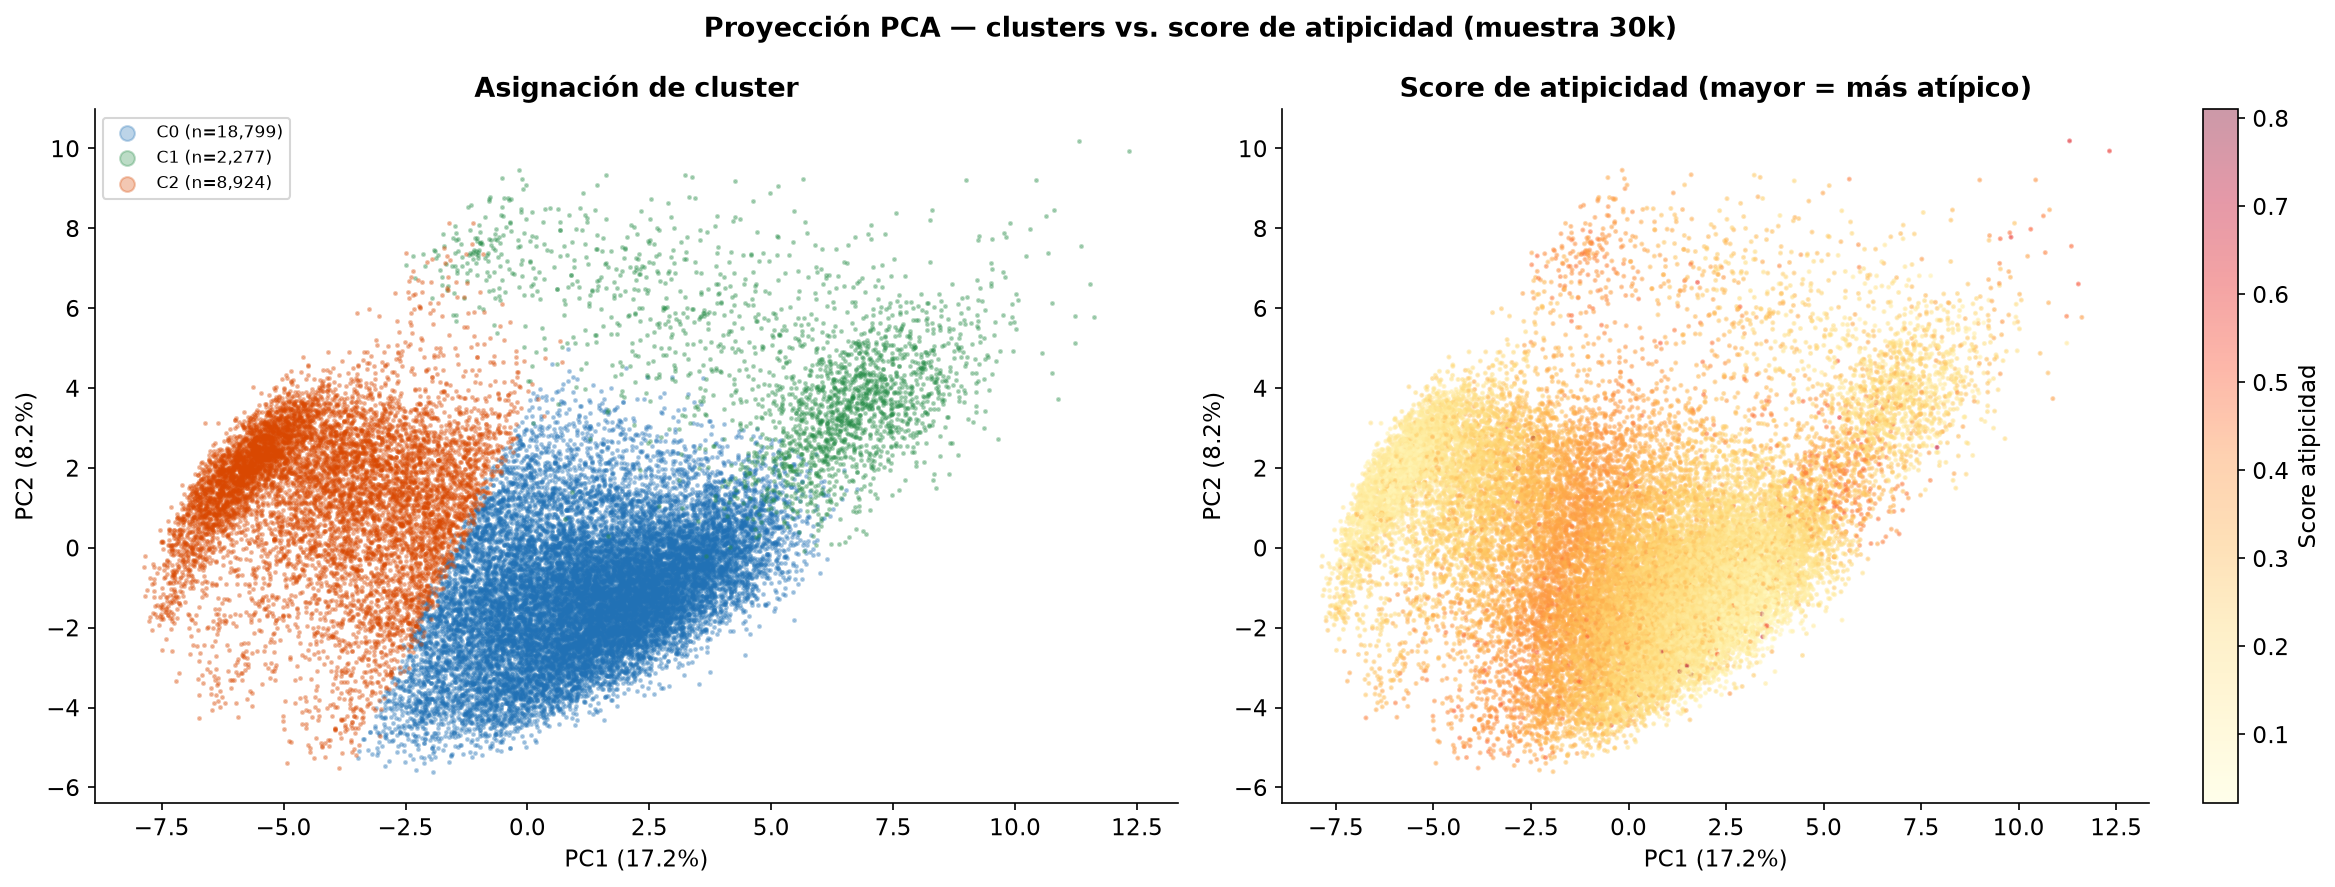

In [17]:
# FIGURA B — Dispersión PCA coloreada por score de atipicidad
pca_viz = PCA(n_components=2, random_state=42)
np.random.seed(42)
idx_viz2 = np.random.choice(len(X_arr), size=30_000, replace=False)
X_pca2 = pca_viz.fit_transform(X_arr[idx_viz2])
scores_viz = score_combinado[idx_viz2]
labels_viz2 = labels_score[idx_viz2]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo — clusters
for k in range(3):
    mask = labels_viz2 == k
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    c=COLORES[k], alpha=0.3, s=2,
                    label=f"C{k} (n={mask.sum():,})")
axes[0].set_title("Asignación de cluster", fontweight="bold")
axes[0].set_xlabel("PC1 (17.2%)")
axes[0].set_ylabel("PC2 (8.2%)")
axes[0].legend(markerscale=5, fontsize=8)

# Panel derecho — score de atipicidad
sc = axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1],
                     c=scores_viz, cmap="YlOrRd",
                     alpha=0.4, s=2)
plt.colorbar(sc, ax=axes[1], label="Score atipicidad")
axes[1].set_title("Score de atipicidad (mayor = más atípico)",
                  fontweight="bold")
axes[1].set_xlabel("PC1 (17.2%)")
axes[1].set_ylabel("PC2 (8.2%)")

fig.suptitle("Proyección PCA — clusters vs. score de atipicidad (muestra 30k)",
             fontweight="bold")
plt.tight_layout()
plt.savefig(config.OUT_DIR / "fig16_score_pca_gradiente.png",
            bbox_inches="tight")
plt.show()

In [18]:
# TABLA A — Perfil comparativo: contribuyente típico vs. atípico por cluster
vars_perfil = [
    "tot_v_grav_nta", "tot_iva_causado", "reca_total_f05",
    "tasa_omision", "promedio_dias_demora", "pct_decl_con_mora",
    "flag_sin_recaudacion_f05", "flg_es_retenedor",
]
vars_perfil_pres = [v for v in vars_perfil if v in df.columns]

print("PERFIL: TÍPICO (P10-P50) vs. ATÍPICO (P95+) POR CLUSTER")
print("=" * 70)

df_full = df.copy()
df_full["score_atipicidad"] = df_scores.set_index("ID").loc[
    df_full["ID"], "score_atipicidad"].values
df_full["percentil_ic"] = df_scores.set_index("ID").loc[
    df_full["ID"], "percentil_intracluster"].values

for k in [1, 0, 2]:
    mask_k = df_full["cluster_km3"] == k
    tipico   = df_full.loc[mask_k & (df_full["percentil_ic"] <= 50)]
    atipico  = df_full.loc[mask_k & (df_full["percentil_ic"] >= 95)]
    
    print(f"\nCluster {k} — {NOMBRES[k]}")
    print(f"  N típicos (≤P50): {len(tipico):,}  |  N atípicos (≥P95): {len(atipico):,}")
    print(f"  {'Variable':<30s} {'Típico (mediana)':>18s} {'Atípico (mediana)':>18s}")
    print("  " + "-" * 68)
    for v in vars_perfil_pres:
        med_tip = tipico[v].median()
        med_ati = atipico[v].median()
        print(f"  {v:<30s} {med_tip:>18.2f} {med_ati:>18.2f}")

PERFIL: TÍPICO (P10-P50) vs. ATÍPICO (P95+) POR CLUSTER

Cluster 1 — Cluster 1 — Grandes/cumplimiento alto
  N típicos (≤P50): 30,490  |  N atípicos (≥P95): 3,050
  Variable                         Típico (mediana)  Atípico (mediana)
  --------------------------------------------------------------------
  tot_v_grav_nta                         1506258.05         1585978.79
  tot_iva_causado                          80594.98           81689.97
  reca_total_f05                           32755.38           65811.99
  tasa_omision                                 0.00               0.00
  promedio_dias_demora                         0.91               0.90
  pct_decl_con_mora                            0.04               0.06
  flag_sin_recaudacion_f05                     0.00               0.00
  flg_es_retenedor                             1.00               1.00

Cluster 0 — Cluster 0 — Medianos/pago parcial
  N típicos (≤P50): 249,911  |  N atípicos (≥P95): 24,992
  Variable            

In [19]:
# TABLA B — Cuántos contribuyentes en cada nivel de prioridad
print("CONTRIBUYENTES POR NIVEL DE PRIORIDAD OPERATIVA")
print("=" * 60)
print("Nivel 5 = top 1% más atípico dentro del cluster")
print("Nivel 4 = top 1%-5%")
print("Nivel 3 = top 5%-10%")
print("Nivel 2 = top 10%-20%")
print("Nivel 1 = resto")
print()

resumen_niveles = (df_scores
    .groupby(["cluster_km3", "nivel_prioridad"])
    .size()
    .reset_index(name="n")
)
resumen_niveles["% del cluster"] = resumen_niveles.apply(
    lambda r: r["n"] / (df_scores["cluster_km3"] == r["cluster_km3"]).sum() * 100,
    axis=1
).round(2)

for k in [1, 0, 2]:
    sub = resumen_niveles[resumen_niveles["cluster_km3"] == k].sort_values(
        "nivel_prioridad", ascending=False)
    n_total = (df_scores["cluster_km3"] == k).sum()
    print(f"Cluster {k} (n total={n_total:,}):")
    print(f"  {'Nivel':>6}  {'N':>10}  {'%':>8}")
    for _, row in sub.iterrows():
        print(f"  {int(row['nivel_prioridad']):>6}  "
              f"{int(row['n']):>10,}  {row['% del cluster']:>7.2f}%")
    print()

CONTRIBUYENTES POR NIVEL DE PRIORIDAD OPERATIVA
Nivel 5 = top 1% más atípico dentro del cluster
Nivel 4 = top 1%-5%
Nivel 3 = top 5%-10%
Nivel 2 = top 10%-20%
Nivel 1 = resto

Cluster 1 (n total=60,980):
   Nivel           N         %
       5         610     1.00%
       4       2,439     4.00%
       3       3,049     5.00%
       2       6,098    10.00%
       1      48,784    80.00%

Cluster 0 (n total=499,822):
   Nivel           N         %
       5       4,999     1.00%
       4      19,993     4.00%
       3      24,991     5.00%
       2      49,982    10.00%
       1     399,857    80.00%

Cluster 2 (n total=236,359):
   Nivel           N         %
       5       2,364     1.00%
       4       9,454     4.00%
       3      11,818     5.00%
       2      23,636    10.00%
       1     189,087    80.00%



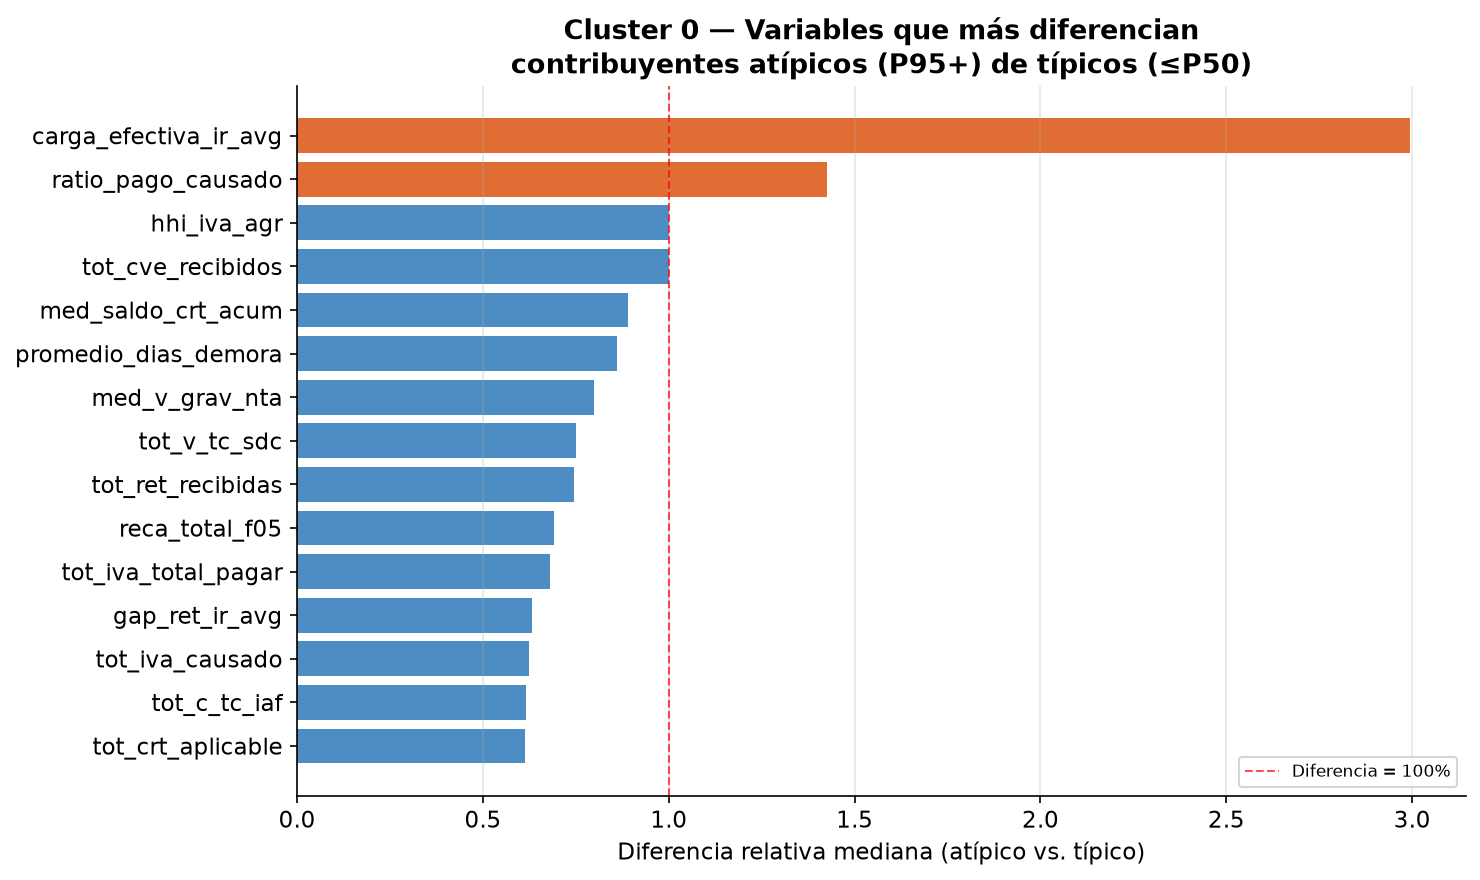

In [20]:
# FIGURA C — Top variables que separan atípicos del centroide (Cluster 0)
# Diferencia de medias entre atípicos P95+ y típicos P50- en el cluster 0
k_analisis = 0
mask_k0 = df_full["cluster_km3"] == k_analisis
tipico_k0  = df_full.loc[mask_k0 & (df_full["percentil_ic"] <= 50)]
atipico_k0 = df_full.loc[mask_k0 & (df_full["percentil_ic"] >= 95)]

vars_cluster = [v for v in config.CLUSTER_VARS_FINAL if v in df_full.columns]
diff_medias = {}
for v in vars_cluster:
    med_tip = tipico_k0[v].median()
    med_ati = atipico_k0[v].median()
    if med_tip != 0:
        diff_medias[v] = abs(med_ati - med_tip) / (abs(med_tip) + 1e-9)
    else:
        diff_medias[v] = abs(med_ati - med_tip)

top_vars = sorted(diff_medias.items(), key=lambda x: x[1], reverse=True)[:15]
vars_top = [v for v, _ in top_vars]
diffs_top = [d for _, d in top_vars]

fig, ax = plt.subplots(figsize=(10, 6))
colores_bar = ["#d94801" if diff_medias[v] > 1 else "#2171b5" for v in vars_top]
ax.barh(vars_top[::-1], diffs_top[::-1], color=colores_bar[::-1], alpha=0.8)
ax.set_xlabel("Diferencia relativa mediana (atípico vs. típico)")
ax.set_title("Cluster 0 — Variables que más diferencian\n"
             "contribuyentes atípicos (P95+) de típicos (≤P50)",
             fontweight="bold")
ax.axvline(x=1.0, color="red", linestyle="--", linewidth=1, 
           alpha=0.7, label="Diferencia = 100%")
ax.legend(fontsize=8)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(config.OUT_DIR / "fig17_top_vars_atipicos_c0.png",
            bbox_inches="tight")
plt.show()

In [21]:
# Guardar dataset de scores
SCORES_FILE = config.DATA_DIR / "B03_SCORES_ATIPICIDAD.parquet"
df_scores.to_parquet(SCORES_FILE, engine="pyarrow",
                     compression="snappy", index=False)

size_mb = SCORES_FILE.stat().st_size / 1e6
print(f"Scores guardados: {SCORES_FILE}")
print(f"Shape : {df_scores.shape[0]:,} filas × {df_scores.shape[1]} columnas")
print(f"Tamaño: {size_mb:.1f} MB")
print()
print("Columnas del archivo:")
for col in df_scores.columns:
    print(f"  {col}")

Scores guardados: D:\inf_sri_hist3\z_CLUSTER\data\B03_SCORES_ATIPICIDAD.parquet
Shape : 797,161 filas × 9 columnas
Tamaño: 32.6 MB

Columnas del archivo:
  ID
  cluster_km3
  dist_centroide
  dist_centroide_norm
  silueta_individual
  silueta_norm_inv
  score_atipicidad
  percentil_intracluster
  nivel_prioridad


In [22]:
# Verificación de alineación ID entre df_full y df_scores
ids_df = set(df["ID"].values)
ids_scores = set(df_scores["ID"].values)

print(f"IDs en df           : {len(ids_df):,}")
print(f"IDs en df_scores    : {len(ids_scores):,}")
print(f"IDs en común        : {len(ids_df & ids_scores):,}")
print(f"IDs solo en df      : {len(ids_df - ids_scores):,}")
print(f"IDs solo en scores  : {len(ids_scores - ids_df):,}")

# Verificar que el merge de scores al df fue correcto
n_sin_score = df_full["score_atipicidad"].isnull().sum() \
    if "score_atipicidad" in df_full.columns else "columna no existe"
print(f"Filas sin score en df_full: {n_sin_score}")

IDs en df           : 797,161
IDs en df_scores    : 797,161
IDs en común        : 797,161
IDs solo en df      : 0
IDs solo en scores  : 0
Filas sin score en df_full: 0


In [23]:
import sys, os
ROOT = r"D:\inf_sri_hist3\z_CLUSTER"
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

import config
import importlib
importlib.reload(config)

import pandas as pd
import numpy as np

# Cargar dataset completo con etiquetas
B00 = pd.read_parquet(config.DATA_DIR / "B00_DATASET_ANALITICO_INTEGRADO.parquet")
labels = pd.read_parquet(config.DATA_DIR / "B02_LABELS_CLUSTERING.parquet")
df = B00.merge(labels, on="ID")

# Calcular ratio pago sobre causado por cluster
# ratio_pago_causado ya existe en el dataset
for c in [0, 1, 2]:
    sub = df[df["cluster_km3"] == c]["ratio_pago_causado"]
    print(f"\nCluster {c} — ratio_pago_causado:")
    print(f"  Mediana:        {sub.median():.4f}")
    print(f"  Media:          {sub.mean():.4f}")
    print(f"  % con ratio>=1: {(sub >= 1).mean()*100:.1f}%")
    print(f"  % con ratio==0: {(sub == 0).mean()*100:.1f}%")


Cluster 0 — ratio_pago_causado:
  Mediana:        0.0412
  Media:          0.8763
  % con ratio>=1: 4.7%
  % con ratio==0: 6.5%

Cluster 1 — ratio_pago_causado:
  Mediana:        0.4846
  Media:          2500.9723
  % con ratio>=1: 23.4%
  % con ratio==0: 0.1%

Cluster 2 — ratio_pago_causado:
  Mediana:        1.0000
  Media:          234.4724
  % con ratio>=1: 23.6%
  % con ratio==0: 5.6%
